Epoch 1/20 - Train Acc: 0.4540, Test Acc: 0.4320
Epoch 2/20 - Train Acc: 0.5745, Test Acc: 0.5140
Epoch 3/20 - Train Acc: 0.7370, Test Acc: 0.7160
Epoch 4/20 - Train Acc: 0.8295, Test Acc: 0.7700
Epoch 5/20 - Train Acc: 0.8230, Test Acc: 0.7620
Epoch 6/20 - Train Acc: 0.8640, Test Acc: 0.8300
Epoch 7/20 - Train Acc: 0.8610, Test Acc: 0.8320
Epoch 8/20 - Train Acc: 0.8855, Test Acc: 0.8560
Epoch 9/20 - Train Acc: 0.8920, Test Acc: 0.8640
Epoch 10/20 - Train Acc: 0.9030, Test Acc: 0.8580
Epoch 11/20 - Train Acc: 0.9025, Test Acc: 0.8700
Epoch 12/20 - Train Acc: 0.9140, Test Acc: 0.8760
Epoch 13/20 - Train Acc: 0.9170, Test Acc: 0.8800
Epoch 14/20 - Train Acc: 0.9230, Test Acc: 0.8780
Epoch 15/20 - Train Acc: 0.9275, Test Acc: 0.8760
Epoch 16/20 - Train Acc: 0.9245, Test Acc: 0.8760
Epoch 17/20 - Train Acc: 0.9370, Test Acc: 0.8940
Epoch 18/20 - Train Acc: 0.9320, Test Acc: 0.8860
Epoch 19/20 - Train Acc: 0.9365, Test Acc: 0.8860
Epoch 20/20 - Train Acc: 0.9425, Test Acc: 0.8960


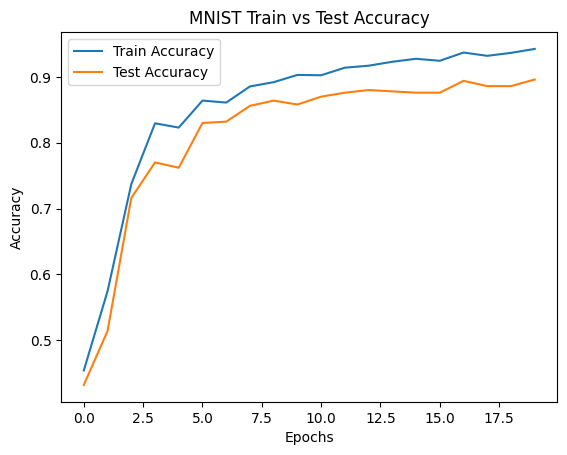

In [11]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt


mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)
X = X[:2500]
y = y[:2500]


encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))


X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)


input_dim = X_train.shape[1]  
hidden_dim = 128
output_dim = 10
lr = 0.1
epochs = 20
batch_size = 64
drop_prob = 0.5
lambda_reg = 0.001


np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))


def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))



def forward(X, W1, b1, W2, b2, drop_prob=0.0, train=True):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    mask = None
    if train and drop_prob > 0.0:
        mask = (np.random.rand(*a1.shape) > drop_prob) / (1 - drop_prob)
        a1 *= mask
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2, mask


def backward(X, y, z1, a1, a2, W1, W2, b1, b2, mask=None, lr=0.01, lambda_reg=0.001):
    m = X.shape[0]
    dz2 = a2 - y
    dW2 = (a1.T @ dz2) / m + lambda_reg * W2
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    da1 = dz2 @ W2.T
    if mask is not None:
        da1 *= mask
    dz1 = da1 * relu_derivative(z1)
    dW1 = (X.T @ dz1) / m + lambda_reg * W1
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    W1_new = W1 - lr * dW1
    b1_new = b1 - lr * db1
    W2_new = W2 - lr * dW2
    b2_new = b2 - lr * db2
    return W1_new, b1_new, W2_new, b2_new


train_acc_history, test_acc_history = [], []

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        z1, a1, z2, a2, mask = forward(X_batch, W1, b1, W2, b2, drop_prob, train=True)
        W1, b1, W2, b2 = backward(X_batch, y_batch, z1, a1, a2, W1, W2, b1, b2, mask, lr, lambda_reg)
    
  
    _, _, _, train_pred, _ = forward(X_train, W1, b1, W2, b2, drop_prob=0.0, train=False)
    _, _, _, test_pred, _ = forward(X_test, W1, b1, W2, b2, drop_prob=0.0, train=False)
    train_acc = accuracy(y_train, train_pred)
    test_acc = accuracy(y_test, test_pred)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(test_acc_history, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MNIST Train vs Test Accuracy')
plt.legend()
plt.show()

In [13]:

import numpy as np
import json
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)

X = X[:2500]
y = y[:2500]
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)


input_dim = X_train.shape[1]
hidden_dim = 128
output_dim = 10
lr = 0.1
epochs = 15
batch_size = 64
drop_prob = 0.5
lambda_reg = 0.001

np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))


def relu(x): return np.maximum(0, x)
def relu_derivative(x): return (x > 0).astype(float)
def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)
def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

def forward(X, W1, b1, W2, b2, drop_prob=0.0, train=True):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    mask = None
    if train and drop_prob > 0.0:
        mask = (np.random.rand(*a1.shape) > drop_prob) / (1 - drop_prob)
        a1 *= mask
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2, mask

def backward(X, y, z1, a1, a2, W1, W2, b1, b2, mask=None, lr=0.01, lambda_reg=0.001):
    m = X.shape[0]
    dz2 = a2 - y
    dW2 = (a1.T @ dz2)/m + lambda_reg*W2
    db2 = np.sum(dz2, axis=0, keepdims=True)/m
    da1 = dz2 @ W2.T
    if mask is not None:
        da1 *= mask
    dz1 = da1 * relu_derivative(z1)
    dW1 = (X.T @ dz1)/m + lambda_reg*W1
    db1 = np.sum(dz1, axis=0, keepdims=True)/m

    W1_new = W1 - lr*dW1
    b1_new = b1 - lr*db1
    W2_new = W2 - lr*dW2
    b2_new = b2 - lr*db2

    grads = {'dW1': dW1.tolist(), 'db1': db1.tolist(),
             'dW2': dW2.tolist(), 'db2': db2.tolist()}
    return W1_new, b1_new, W2_new, b2_new, grads


train_acc_history = []
test_acc_history = []


with open('mnist_xai_500.json', 'w') as f:
    pass

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        z1, a1, z2, a2, mask = forward(X_batch, W1, b1, W2, b2, drop_prob, train=True)
        W1, b1, W2, b2, grads = backward(X_batch, y_batch, z1, a1, a2, W1, W2, b1, b2, mask, lr, lambda_reg)

  
        batch_record = {
            'epoch': epoch+1,
            'batch_index': i//batch_size,
            'inputs': X_batch.tolist(),
            'true_labels': y_batch.tolist(),
            'predictions': a2.tolist(),
            'weights': {'W1': W1.tolist(), 'b1': b1.tolist(),
                        'W2': W2.tolist(), 'b2': b2.tolist()},
            'gradients': grads,
            'activations': {'z1': z1.tolist(), 'a1': a1.tolist(),
                            'z2': z2.tolist(), 'a2': a2.tolist()},
            'dropout_mask': mask.tolist() if mask is not None else None
        }

        with open('mnist_xai_500.json', 'a') as f:
            json.dump(batch_record, f)
            f.write('\n')

 
    _, _, _, train_pred, _ = forward(X_train, W1, b1, W2, b2, drop_prob=0.0, train=False)
    _, _, _, test_pred, _ = forward(X_test, W1, b1, W2, b2, drop_prob=0.0, train=False)
    train_acc = accuracy(y_train, train_pred)
    test_acc = accuracy(y_test, test_pred)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

print("✅ XAI data saved batch by batch in mnist_xai_500.json")

Epoch 1/15 - Train Acc: 0.4540, Test Acc: 0.4320
Epoch 2/15 - Train Acc: 0.5745, Test Acc: 0.5140
Epoch 3/15 - Train Acc: 0.7370, Test Acc: 0.7160
Epoch 4/15 - Train Acc: 0.8295, Test Acc: 0.7700
Epoch 5/15 - Train Acc: 0.8230, Test Acc: 0.7620
Epoch 6/15 - Train Acc: 0.8640, Test Acc: 0.8300
Epoch 7/15 - Train Acc: 0.8610, Test Acc: 0.8320
Epoch 8/15 - Train Acc: 0.8855, Test Acc: 0.8560
Epoch 9/15 - Train Acc: 0.8920, Test Acc: 0.8640
Epoch 10/15 - Train Acc: 0.9030, Test Acc: 0.8580
Epoch 11/15 - Train Acc: 0.9025, Test Acc: 0.8700
Epoch 12/15 - Train Acc: 0.9140, Test Acc: 0.8760
Epoch 13/15 - Train Acc: 0.9170, Test Acc: 0.8800
Epoch 14/15 - Train Acc: 0.9230, Test Acc: 0.8780
Epoch 15/15 - Train Acc: 0.9275, Test Acc: 0.8760
✅ XAI data saved batch by batch in mnist_xai_500.json


In [15]:
np.savez_compressed("mnist_xai_2500.npz", W1=W1, W2=W2, b1=b1, b2=b2)

In [8]:
print(X_train.shape)

(56000, 784)
